In [ ]:
pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import torch
from torch import nn
from scipy.stats import ttest_rel
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
size_text =24
plt.rcParams.update({
    'font.family': 'serif',
    'text.usetex': False,  # Evita usar LaTeX
    'axes.titlesize': size_text,
    'xtick.labelsize': size_text,
    'ytick.labelsize': size_text,
    'legend.fontsize': size_text,
    'ytick.major.size': 2,
    'xtick.major.size': 2,
})

w = 10
h = 6

#  Dataset

In [ ]:
df = pd.read_csv("factores_forma_uniformes_30000_R_0.1.csv")
X = df[["h", "k", "d"]].values
y = df["F"].values.reshape(-1, 1)

In [ ]:
df.head()

,h,k,d,F
0,-50.0,-50.0,10,2.790539e-07
1,-50.0,-50.0,15,4.182728e-07
2,-50.0,-50.0,20,5.096276e-07
3,-50.0,-50.0,25,5.664967e-07
4,-50.0,-50.0,30,6.001080e-07


# Train - Test Set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data scaling

In [ ]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()



X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

In [ ]:
valor_d = 10
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)
H, K = np.meshgrid(h_vals, k_vals)
D = np.full_like(H, valor_d)
X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Convert to tensors

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled.reshape(-1, 1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled.reshape(-1, 1), dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds  = TensorDataset(X_test_tensor, y_test_tensor)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
test_dl  = DataLoader(test_ds , batch_size=256, shuffle=False)

# Build neural network

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = MLP()



# Training

In [ ]:
# Funcion de perdida

loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Entrenamiento de la red


def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

    # Evaluar al final de cada época
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")


Epoch   1 | RMSE_train: 1.8639e-01 | RMSE_test: 1.8733e-01
Epoch  20 | RMSE_train: 4.3246e-02 | RMSE_test: 4.5168e-02
Epoch  40 | RMSE_train: 2.7033e-02 | RMSE_test: 2.8277e-02
Epoch  60 | RMSE_train: 2.5919e-02 | RMSE_test: 2.6887e-02
Epoch  80 | RMSE_train: 1.3302e-02 | RMSE_test: 1.4091e-02
Epoch 100 | RMSE_train: 1.0313e-02 | RMSE_test: 1.0606e-02
Epoch 120 | RMSE_train: 8.6328e-03 | RMSE_test: 8.7616e-03
Epoch 140 | RMSE_train: 5.2698e-03 | RMSE_test: 5.5373e-03
Epoch 160 | RMSE_train: 9.2990e-03 | RMSE_test: 9.5650e-03
Epoch 180 | RMSE_train: 9.5589e-03 | RMSE_test: 9.8584e-03
Epoch 200 | RMSE_train: 8.9074e-03 | RMSE_test: 9.3230e-03
Epoch 220 | RMSE_train: 6.2402e-03 | RMSE_test: 6.5888e-03
Epoch 240 | RMSE_train: 4.8968e-03 | RMSE_test: 5.2727e-03
Epoch 260 | RMSE_train: 1.5723e-02 | RMSE_test: 1.5820e-02
Epoch 280 | RMSE_train: 1.2614e-02 | RMSE_test: 1.3258e-02
Epoch 300 | RMSE_train: 4.7765e-03 | RMSE_test: 4.8914e-03


#  Measure execution times

In [ ]:
import time


loss_fn   = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


def rmse(pred, target):
    return torch.sqrt(nn.functional.mse_loss(pred, target))

EPOCHS = 300
train_rmse_list = []
test_rmse_list = []


t0 = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train_tensor)
        rmse_train = rmse(y_pred_train, y_train_tensor).item()

        y_pred_test = model(X_test_tensor)
        rmse_test = rmse(y_pred_test, y_test_tensor).item()

    train_rmse_list.append(rmse_train)
    test_rmse_list.append(rmse_test)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | RMSE_train: {rmse_train:.4e} | RMSE_test: {rmse_test:.4e}")

t1 = time.perf_counter()
T_train_mlp = t1 - t0


model.eval()
with torch.no_grad():
    t2 = time.perf_counter()
    y_pred_test_final = model(X_test_tensor)
    t3 = time.perf_counter()

T_pred_mlp = t3 - t2
N_pred_mlp = X_test_tensor.shape[0]
t_pred_mlp = T_pred_mlp / N_pred_mlp

print(f" MLP training time: {T_train_mlp:.6f} s")
print(f" Total MLP prediction time (test set): {T_pred_mlp:.6f} s for {N_pred_mlp} samples")
print(f" MLP prediction time per sample: {t_pred_mlp:.8f} s/sample")

Epoch   1 | RMSE_train: 2.7754e-03 | RMSE_test: 2.9428e-03
Epoch  20 | RMSE_train: 7.2602e-03 | RMSE_test: 7.3063e-03
Epoch  40 | RMSE_train: 3.5304e-03 | RMSE_test: 3.7384e-03
Epoch  60 | RMSE_train: 4.9537e-03 | RMSE_test: 5.1871e-03
Epoch  80 | RMSE_train: 4.2632e-03 | RMSE_test: 4.4584e-03
Epoch 100 | RMSE_train: 6.2109e-03 | RMSE_test: 6.4404e-03
Epoch 120 | RMSE_train: 4.8772e-03 | RMSE_test: 4.8139e-03
Epoch 140 | RMSE_train: 6.3493e-03 | RMSE_test: 6.6452e-03
Epoch 160 | RMSE_train: 3.2766e-03 | RMSE_test: 3.4441e-03
Epoch 180 | RMSE_train: 2.8426e-03 | RMSE_test: 2.8829e-03
Epoch 200 | RMSE_train: 2.7041e-03 | RMSE_test: 2.7922e-03
Epoch 220 | RMSE_train: 3.2014e-03 | RMSE_test: 3.3568e-03
Epoch 240 | RMSE_train: 4.9188e-03 | RMSE_test: 4.9721e-03
Epoch 260 | RMSE_train: 2.5047e-03 | RMSE_test: 2.4859e-03
Epoch 280 | RMSE_train: 2.7527e-03 | RMSE_test: 2.8638e-03
Epoch 300 | RMSE_train: 4.4987e-03 | RMSE_test: 4.6513e-03

⏱️ Tiempo ENTRENAMIENTO MLP: 176.778793 s
⏱️ Tiempo PRE

# Metrics

In [ ]:
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).numpy()
    y_test_pred_scaled  = model(X_test_tensor).numpy()

# Desescalar
y_train_pred_real = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_test_pred_real  = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

y_train_real = scaler_y.inverse_transform(y_train_tensor.numpy().reshape(-1, 1))
y_test_real  = scaler_y.inverse_transform(y_test_tensor.numpy().reshape(-1, 1))

## Metrics of training

In [ ]:
mse_train  = mean_squared_error(y_train_real, y_train_pred_real)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train_real, y_train_pred_real)
r2_train   = r2_score(y_train_real, y_train_pred_real)

print("ENTENAMIENTO:")
print(f"MSE:  {mse_train:.3e}")
print(f"RMSE: {rmse_train:.3e}")
print(f"MAE:  {mae_train:.3e}")
print(f"R²:   {r2_train:.8f}")

ENTENAMIENTO:
MSE:  3.187e-17
RMSE: 5.645e-09
MAE:  3.771e-09
R²:   0.99994802


## Metrics of testing

In [ ]:
mse_test  = mean_squared_error(y_test_real, y_test_pred_real)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_real, y_test_pred_real)
r2_test   = r2_score(y_test_real, y_test_pred_real)

print("TEST:")
print(f"MSE:  {mse_test:.3e}")
print(f"RMSE: {rmse_test:.3e}")
print(f"MAE:  {mae_test:.3e}")
print(f"R²:   {r2_test:.8f}")

TEST:
MSE:  3.460e-17
RMSE: 5.882e-09
MAE:  3.853e-09
R²:   0.99994290


# mape

In [ ]:
mape = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real)) * 100
print(f" MAPE: {mape:.2f}%")

 MAPE: 0.30%


In [ ]:
tolerancia = 0.05
porcentaje_buenas = np.mean(np.abs((y_test_real - y_test_pred_real) / y_test_real) < tolerancia) * 100
print(f"Predicciones con <5% error: {porcentaje_buenas:.2f}%")

Predicciones con <5% error: 99.97%


# Heatmap of predictions

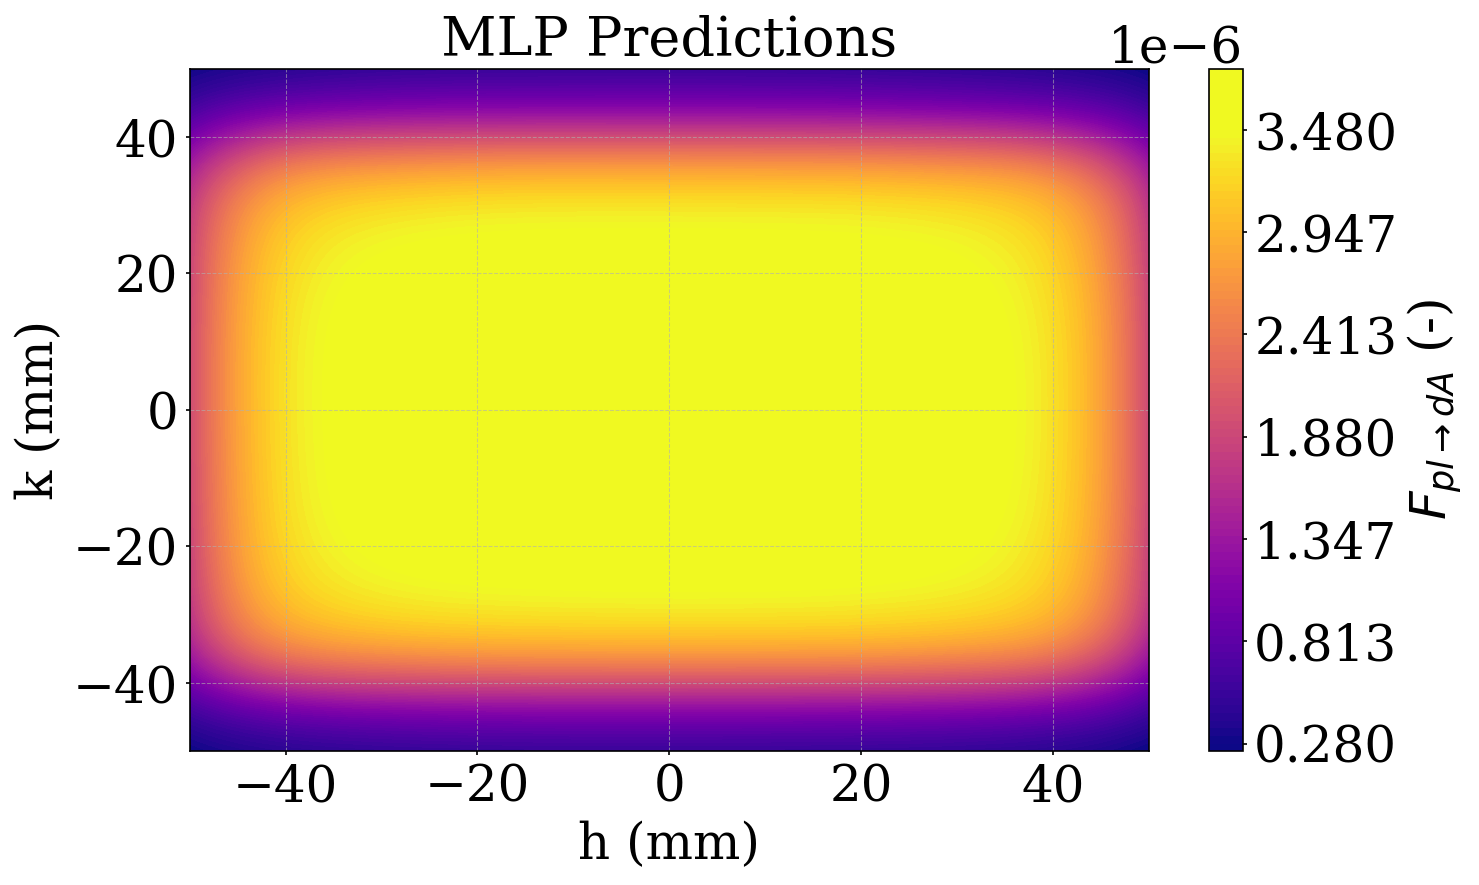

In [ ]:
# Grilla de predicción para MLP
valor_d = 10  # Valor fijo para la tercera variable
h_vals = np.linspace(-50, 50, 100)
k_vals = np.linspace(-50, 50, 100)

H, K = np.meshgrid(h_vals, k_vals)        # (100, 100)
D = np.full_like(H, valor_d)              # (100, 100)

X_pred = np.stack([H.ravel(), K.ravel(), D.ravel()], axis=1)
X_pred_scaled = scaler_X.transform(X_pred)

# Predicción con la red neuronal entrenada
with torch.no_grad():
    F_pred_scaled = model(torch.tensor(X_pred_scaled, dtype=torch.float32)).cpu().numpy()

# Desescalar
F_pred = scaler_y.inverse_transform(F_pred_scaled.reshape(-1, 1))
F_pred = F_pred.reshape(H.shape)

# Parámetros de visualización
vmin = 0.28e-6
vmax = 3.48e-6
ticks = np.linspace(vmin, vmax, 7)

fig, ax = plt.subplots(1, 1, figsize=(w, h), dpi=150)

contour = ax.contourf(H, K, F_pred, levels=100, vmin=vmin, vmax=vmax, cmap='plasma')
cbar = fig.colorbar(contour)
cbar.set_label(label=r'$F_{pl\to dA}$ (-)', size=size_text)
cbar.set_ticks(ticks)

ax.set_title("MLP Predictions", fontsize=size_text + 2)
ax.set_xlabel("h (mm)", fontsize=size_text)
ax.set_ylabel("k (mm)", fontsize=size_text)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()

# Guardar igual que SVR
plt.savefig("Heatmap_mlp_predictions.png", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.pdf", dpi=400, bbox_inches='tight')
#plt.savefig("Heatmap_mlp_predictions.eps", dpi=400, bbox_inches='tight')
plt.show()